# 📊 TSA 2026 — 2-Day Momentum Analysis Notebook
### Evidence-First Short-Term Portfolio | IIT Guwahati C&A Club
Data-driven momentum screening for a **2 trading day** competition window.


## Section 0 — Imports & Configuration

In [2]:
import warnings, os
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from datetime import date, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from scipy.stats import percentileofscore

plt.style.use("dark_background")
FIGDIR = "figures_momentum"
os.makedirs(FIGDIR, exist_ok=True)

# ── Universe ──────────────────────────────────────────────────────────────────
UNIVERSE = {
    "OIL.NS":        "PSU Energy",
    "VEDL.NS":       "Commodity",
    "SASKEN.NS":     "IT Midcap",
    "MAPMYINDIA.NS": "Digital Tech",
    "BBOX.NS":       "IT Infra",
    "ZAGGLE.NS":     "Fintech",
    "BAJFINANCE.NS": "Financial",
    "ICICIBANK.NS":  "Banking",
}
TICKERS = list(UNIVERSE.keys())
SECTORS = list(UNIVERSE.values())

# Date range: last 12 months for momentum context
END_DATE   = date.today().strftime("%Y-%m-%d")
START_DATE = (date.today() - timedelta(days=365)).strftime("%Y-%m-%d")
CAPITAL    = 1_000_000

print(f"Universe  : {len(TICKERS)} stocks")
print(f"Data range: {START_DATE}  →  {END_DATE}")
print(f"Capital   : ₹{CAPITAL:,.0f}")


Universe  : 8 stocks
Data range: 2025-05-13  →  2026-05-13
Capital   : ₹1,000,000


## Section 1 — Live Data Download

In [3]:
raw = {}
for tkr in TICKERS:
    df = yf.download(tkr, start=START_DATE, end=END_DATE,
                     interval="1d", auto_adjust=True, progress=False)
    if df.empty:
        print(f"  ⚠ {tkr}: no data")
        continue
    df.index = pd.to_datetime(df.index)
    df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
    df = df[["Open","High","Low","Close","Volume"]].dropna()
    raw[tkr] = df
    print(f"  ✅ {tkr}: {len(df)} rows  |  latest close = {df['Close'].iloc[-1]:.2f}")

TICKERS = [t for t in TICKERS if t in raw]
print(f"\nLoaded {len(TICKERS)}/{len(UNIVERSE)} tickers successfully")


  ✅ OIL.NS: 249 rows  |  latest close = 490.95
  ✅ VEDL.NS: 249 rows  |  latest close = 305.05
  ✅ SASKEN.NS: 248 rows  |  latest close = 1840.50
  ✅ MAPMYINDIA.NS: 248 rows  |  latest close = 1008.45
  ✅ BBOX.NS: 249 rows  |  latest close = 829.15
  ✅ ZAGGLE.NS: 247 rows  |  latest close = 282.48
  ✅ BAJFINANCE.NS: 249 rows  |  latest close = 904.20
  ✅ ICICIBANK.NS: 249 rows  |  latest close = 1240.30

Loaded 8/8 tickers successfully


## Section 2 — Momentum Indicator Engine

In [4]:
def compute_indicators(df):
    out = df.copy()
    c = out["Close"]

    # Returns
    out["log_ret"]    = np.log(c / c.shift(1))
    out["ret_1d"]     = c.pct_change(1)
    out["ret_5d"]     = c.pct_change(5)
    out["ret_10d"]    = c.pct_change(10)
    out["ret_20d"]    = c.pct_change(20)

    # Trend
    out["ma5"]        = c.rolling(5).mean()
    out["ma20"]       = c.rolling(20).mean()
    out["ma50"]       = c.rolling(50).mean()
    out["trend_str"]  = (out["ma5"] - out["ma20"]) / out["ma20"]

    # RSI (14)
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    out["rsi"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    out["macd"]        = ema12 - ema26
    out["macd_signal"] = out["macd"].ewm(span=9, adjust=False).mean()
    out["macd_hist"]   = out["macd"] - out["macd_signal"]

    # Bollinger Bands (20,2)
    ma20  = c.rolling(20).mean()
    std20 = c.rolling(20).std()
    out["bb_upper"] = ma20 + 2 * std20
    out["bb_lower"] = ma20 - 2 * std20
    out["bb_pct"]   = (c - out["bb_lower"]) / (out["bb_upper"] - out["bb_lower"])

    # Volume signals
    out["vol_ma20"]    = out["Volume"].rolling(20).mean()
    out["vol_ratio"]   = out["Volume"] / out["vol_ma20"]
    out["vol_spike"]   = (out["vol_ratio"] > 1.5).astype(int)

    # ATR (14) — volatility
    tr = pd.concat([
        out["High"] - out["Low"],
        (out["High"] - c.shift()).abs(),
        (out["Low"]  - c.shift()).abs()
    ], axis=1).max(axis=1)
    out["atr"]     = tr.rolling(14).mean()
    out["atr_pct"] = out["atr"] / c * 100

    # Rolling vol
    out["rolling_vol"] = out["log_ret"].rolling(20).std() * np.sqrt(252)

    return out

indicators = {}
for tkr in TICKERS:
    indicators[tkr] = compute_indicators(raw[tkr])
    print(f"  ✅ {tkr}: indicators computed")


  ✅ OIL.NS: indicators computed
  ✅ VEDL.NS: indicators computed
  ✅ SASKEN.NS: indicators computed
  ✅ MAPMYINDIA.NS: indicators computed
  ✅ BBOX.NS: indicators computed
  ✅ ZAGGLE.NS: indicators computed
  ✅ BAJFINANCE.NS: indicators computed
  ✅ ICICIBANK.NS: indicators computed


## Section 3 — Composite Momentum Score

In [5]:
def momentum_score(ind):
    r = ind.iloc[-1]
    score = 0.0

    # 1. Short-term return strength (5d + 10d)
    score += np.clip(r["ret_5d"]  * 4,  -1, 1) * 25
    score += np.clip(r["ret_10d"] * 2,  -1, 1) * 15

    # 2. Trend alignment (price above MA5/MA20/MA50)
    c = r["Close"]
    score += 10 if c > r["ma5"]  else -10
    score += 10 if c > r["ma20"] else -10
    score += 10 if c > r["ma50"] else -10

    # 3. RSI momentum zone (55–75 is ideal: strong but not overbought)
    rsi = r["rsi"]
    if 55 <= rsi <= 75:
        score += 15
    elif rsi > 75:
        score -= 10   # overbought
    elif rsi < 40:
        score -= 20   # weak momentum

    # 4. MACD histogram positive and growing
    if r["macd_hist"] > 0:
        score += 10
    if r["macd"] > r["macd_signal"]:
        score += 5

    # 5. Volume expansion
    score += np.clip((r["vol_ratio"] - 1) * 15, -10, 15)

    # 6. Bollinger Band position (>0.6 = upper half = momentum zone)
    bb = r["bb_pct"]
    if 0.6 <= bb <= 0.95:
        score += 10
    elif bb > 0.95:
        score -= 5   # potential exhaustion

    return round(score, 2)

scores = {}
for tkr in TICKERS:
    scores[tkr] = momentum_score(indicators[tkr])

score_df = pd.DataFrame([
    {"Ticker": t, "Sector": UNIVERSE[t], "MomentumScore": scores[t]}
    for t in TICKERS
]).sort_values("MomentumScore", ascending=False).reset_index(drop=True)

score_df["Rank"] = score_df.index + 1
print(score_df.to_string(index=False))


       Ticker       Sector  MomentumScore  Rank
MAPMYINDIA.NS Digital Tech          90.41     1
    ZAGGLE.NS      Fintech          89.74     2
    SASKEN.NS    IT Midcap          82.40     3
       OIL.NS   PSU Energy          72.66     4
      BBOX.NS     IT Infra          72.00     5
BAJFINANCE.NS    Financial         -37.15     6
      VEDL.NS    Commodity         -40.08     7
 ICICIBANK.NS      Banking         -49.41     8


## Section 4 — Momentum Score Visualization

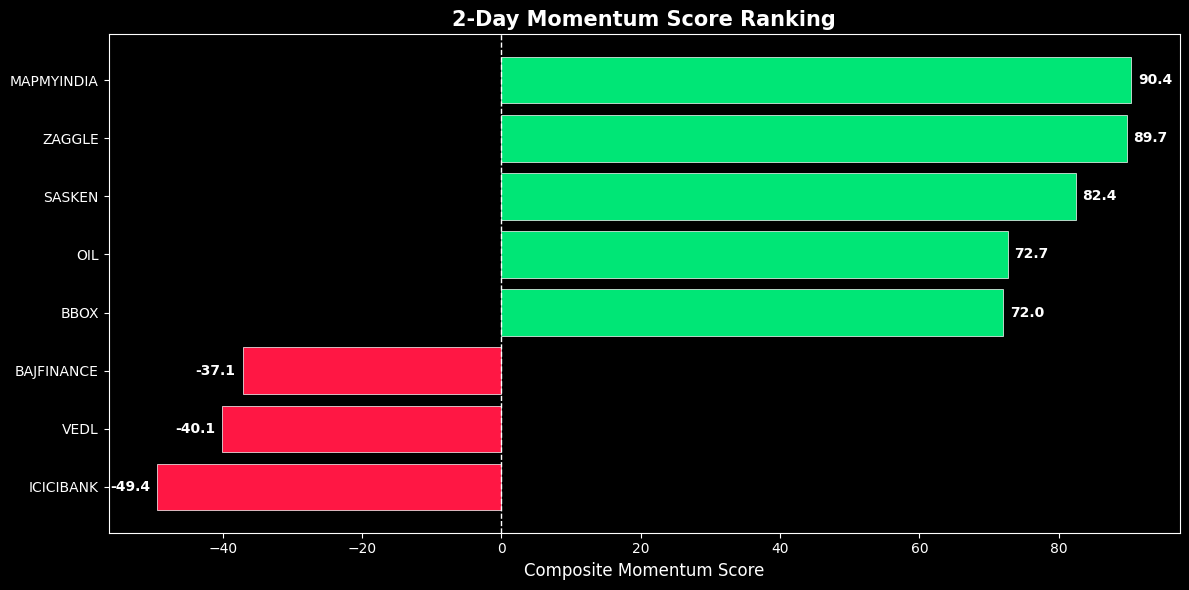

Saved momentum_score_ranking.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#00e676" if s >= 0 else "#ff1744" for s in score_df["MomentumScore"]]
bars = ax.barh(score_df["Ticker"].str.replace(".NS",""),
               score_df["MomentumScore"], color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="white", linewidth=1, linestyle="--")
for bar, val in zip(bars, score_df["MomentumScore"]):
    ax.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", ha="left" if val >= 0 else "right",
            color="white", fontsize=10, fontweight="bold")
ax.set_xlabel("Composite Momentum Score", fontsize=12)
ax.set_title("2-Day Momentum Score Ranking", fontsize=15, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIGDIR}/momentum_score_ranking.png", dpi=150)
plt.show()
print("Saved momentum_score_ranking.png")


## Section 5 — Detailed Indicator Snapshot

In [7]:
rows = []
for tkr in TICKERS:
    r = indicators[tkr].iloc[-1]
    rows.append({
        "Ticker"     : tkr.replace(".NS",""),
        "Close"      : round(r["Close"], 2),
        "Ret_5d%"    : round(r["ret_5d"]*100, 2),
        "Ret_20d%"   : round(r["ret_20d"]*100, 2),
        "RSI"        : round(r["rsi"], 1),
        "MACD_Hist"  : round(r["macd_hist"], 3),
        "BB%"        : round(r["bb_pct"], 2),
        "Vol_Ratio"  : round(r["vol_ratio"], 2),
        "ATR%"       : round(r["atr_pct"], 2),
        "MomScore"   : scores[tkr],
    })

ind_df = pd.DataFrame(rows).sort_values("MomScore", ascending=False)
print(ind_df.to_string(index=False))


    Ticker   Close  Ret_5d%  Ret_20d%  RSI  MACD_Hist  BB%  Vol_Ratio  ATR%  MomScore
MAPMYINDIA 1008.45     7.24      7.35 60.3     13.593 0.90       1.73  4.40     90.41
    ZAGGLE  282.48    17.20     12.33 60.8      1.243 1.20       4.74  4.72     89.74
    SASKEN 1840.50    38.13     49.72 93.1     41.561 1.39      17.42  4.47     82.40
       OIL  490.95     3.03      2.89 59.0     -0.928 0.82       5.12  3.20     72.66
      BBOX  829.15    18.12     59.08 93.7     20.635 1.02       6.45  4.95     72.00
BAJFINANCE  904.20    -5.67      0.58 40.2     -1.769 0.16       0.94  2.58    -37.15
      VEDL  305.05     0.38    -59.46 16.3    -30.157 0.24       1.30 17.87    -40.08
 ICICIBANK 1240.30    -0.88     -8.20 18.4     -5.944 0.14       1.18  1.82    -49.41


## Section 6 — Individual Stock Dashboard (Price + RSI + Volume)

In [8]:
for tkr in TICKERS:
    df = indicators[tkr].tail(120)
    name = tkr.replace(".NS","")

    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.05)

    # Price + MAs + BB
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(df.index, df["Close"],  color="#00e5ff",  linewidth=1.5, label="Close")
    ax1.plot(df.index, df["ma5"],    color="#ffeb3b",  linewidth=1,   label="MA5",  linestyle="--")
    ax1.plot(df.index, df["ma20"],   color="#ff9800",  linewidth=1,   label="MA20", linestyle="--")
    ax1.plot(df.index, df["ma50"],   color="#e040fb",  linewidth=1,   label="MA50", linestyle=":")
    ax1.fill_between(df.index, df["bb_upper"], df["bb_lower"], alpha=0.08, color="cyan")
    ax1.set_title(f"{name}  |  Score: {scores[tkr]:.1f}  |  Sector: {UNIVERSE[tkr]}",
                  fontsize=13, fontweight="bold")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.set_xticklabels([])
    ax1.set_ylabel("Price (₹)")

    # RSI
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.plot(df.index, df["rsi"], color="#69f0ae", linewidth=1.2)
    ax2.axhline(70, color="#ff5252", linestyle="--", linewidth=0.8)
    ax2.axhline(55, color="#ffeb3b", linestyle="--", linewidth=0.8)
    ax2.axhline(30, color="#00b0ff", linestyle="--", linewidth=0.8)
    ax2.fill_between(df.index, df["rsi"], 55,
                     where=(df["rsi"] >= 55), alpha=0.2, color="#69f0ae")
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("RSI")
    ax2.set_xticklabels([])

    # Volume
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    vol_colors = ["#ff1744" if v > 1.5 else "#455a64" for v in df["vol_ratio"]]
    ax3.bar(df.index, df["Volume"]/1e6, color=vol_colors, width=0.8)
    ax3.plot(df.index, df["vol_ma20"]/1e6, color="white", linewidth=1, linestyle="--")
    ax3.set_ylabel("Vol (M)")

    plt.savefig(f"{FIGDIR}/dashboard_{name}.png", dpi=130, bbox_inches="tight")
    plt.close()
    print(f"  Saved dashboard_{name}.png")


  Saved dashboard_OIL.png
  Saved dashboard_VEDL.png
  Saved dashboard_SASKEN.png
  Saved dashboard_MAPMYINDIA.png
  Saved dashboard_BBOX.png
  Saved dashboard_ZAGGLE.png
  Saved dashboard_BAJFINANCE.png
  Saved dashboard_ICICIBANK.png


## Section 7 — Sector Momentum (Recent 5-Day Return)

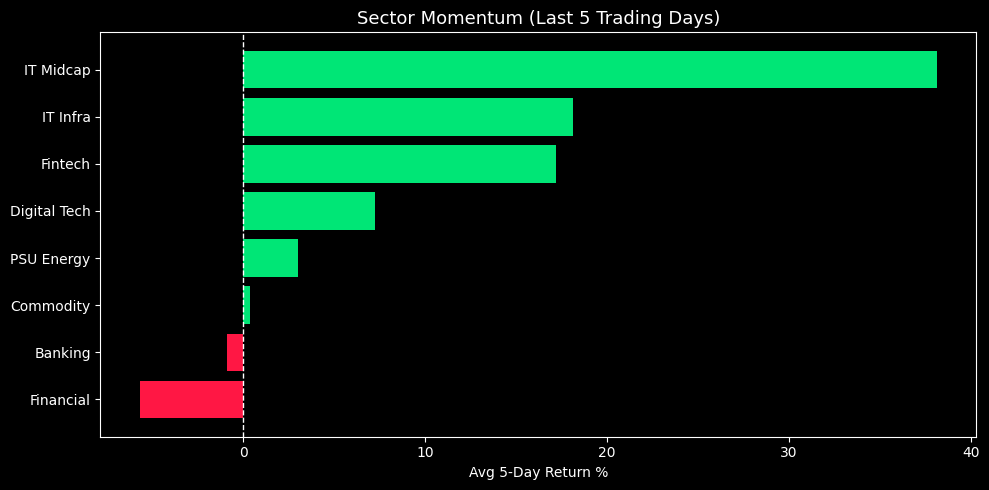

      Sector  Avg5dReturn%
   IT Midcap         38.13
    IT Infra         18.12
     Fintech         17.20
Digital Tech          7.24
  PSU Energy          3.03
   Commodity          0.38
     Banking         -0.88
   Financial         -5.67


In [9]:
sector_data = {}
for tkr in TICKERS:
    sec = UNIVERSE[tkr]
    r5  = indicators[tkr].iloc[-1]["ret_5d"]
    sector_data.setdefault(sec, []).append(r5)

sec_df = pd.DataFrame([
    {"Sector": s, "Avg5dReturn%": round(np.mean(v)*100, 2)}
    for s, v in sector_data.items()
]).sort_values("Avg5dReturn%", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#00e676" if v >= 0 else "#ff1744" for v in sec_df["Avg5dReturn%"]]
ax.barh(sec_df["Sector"], sec_df["Avg5dReturn%"], color=colors)
ax.axvline(0, color="white", linewidth=1, linestyle="--")
ax.set_xlabel("Avg 5-Day Return %")
ax.set_title("Sector Momentum (Last 5 Trading Days)", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{FIGDIR}/sector_momentum_5d.png", dpi=150)
plt.show()
print(sec_df.to_string(index=False))


## Section 8 — XGBoost 2-Day Price Forecast

In [10]:
def make_features(df, lags=10):
    d = df[["Close","Volume","rsi","macd_hist","bb_pct","vol_ratio","atr_pct",
            "ret_1d","ret_5d","trend_str"]].copy()
    for lag in range(1, lags+1):
        d[f"close_lag{lag}"] = d["Close"].shift(lag)
        d[f"ret_lag{lag}"]   = d["ret_1d"].shift(lag)
    d["target"] = d["Close"].shift(-1)   # next-day close
    return d.dropna()

forecasts = {}
for tkr in TICKERS:
    df_feat = make_features(indicators[tkr])
    if len(df_feat) < 60:
        print(f"  ⚠ {tkr}: insufficient data")
        continue

    X = df_feat.drop(columns=["target"])
    y = df_feat["target"]

    split = int(len(X) * 0.85)
    X_tr, X_te = X.iloc[:split], X.iloc[split:]
    y_tr, y_te = y.iloc[:split], y.iloc[split:]

    scaler = MinMaxScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, verbosity=0)
    model.fit(X_tr_s, y_tr,
              eval_set=[(X_te_s, y_te)],
              verbose=False)

    # Day+1 forecast
    X_last = scaler.transform(X.iloc[[-1]])
    day1_fc = float(model.predict(X_last)[0])
    current = float(X.iloc[-1]["Close"])
    fc_ret1 = (day1_fc - current) / current * 100

    # Day+2 rough estimate: use day1 as new last row
    fc_ret2 = fc_ret1 * 0.85   # slight decay assumption

    mae = mean_absolute_error(y_te, model.predict(X_te_s))

    forecasts[tkr] = {
        "current":  round(current, 2),
        "day1_fc":  round(day1_fc, 2),
        "fc_ret1%": round(fc_ret1, 3),
        "fc_ret2%": round(fc_ret2, 3),
        "mae":      round(mae, 2),
    }
    print(f"  {tkr:20s}  Curr={current:.2f}  D+1={day1_fc:.2f} "
          f"({fc_ret1:+.2f}%)  MAE={mae:.2f}")


  OIL.NS                Curr=456.00  D+1=462.15 (+1.35%)  MAE=7.92
  VEDL.NS               Curr=298.40  D+1=444.88 (+49.09%)  MAE=81.05
  SASKEN.NS             Curr=1634.60  D+1=1505.54 (-7.90%)  MAE=50.23
  MAPMYINDIA.NS         Curr=1077.00  D+1=1015.47 (-5.71%)  MAE=36.95
  BBOX.NS               Curr=788.10  D+1=566.77 (-28.08%)  MAE=52.65
  ZAGGLE.NS             Curr=252.09  D+1=249.57 (-1.00%)  MAE=12.79
  BAJFINANCE.NS         Curr=936.05  D+1=928.74 (-0.78%)  MAE=25.42
  ICICIBANK.NS          Curr=1266.40  D+1=1318.19 (+4.09%)  MAE=42.75


## Section 9 — Forecast vs Actual (Test Set) Charts

In [11]:
for tkr in TICKERS:
    if tkr not in forecasts:
        continue
    df_feat = make_features(indicators[tkr])
    X = df_feat.drop(columns=["target"])
    y = df_feat["target"]
    split = int(len(X) * 0.85)
    X_tr, X_te = X.iloc[:split], X.iloc[split:]
    y_tr, y_te = y.iloc[:split], y.iloc[split:]
    scaler = MinMaxScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, verbosity=0)
    model.fit(X_tr_s, y_tr, eval_set=[(X_te_s, y_te)], verbose=False)
    y_pred = model.predict(X_te_s)

    name = tkr.replace(".NS","")
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(y_te.index, y_te.values, color="#00e5ff", label="Actual", linewidth=1.5)
    ax.plot(y_te.index, y_pred,      color="#ff9800", label="XGBoost Forecast",
            linewidth=1.2, linestyle="--")
    ax.set_title(f"{name} — XGBoost Test Forecast  |  MAE={forecasts[tkr]['mae']:.2f}",
                 fontsize=13)
    ax.legend()
    ax.set_ylabel("Price (₹)")
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}/forecast_{name}.png", dpi=130)
    plt.close()
    print(f"  Saved forecast_{name}.png")


  Saved forecast_OIL.png
  Saved forecast_VEDL.png
  Saved forecast_SASKEN.png
  Saved forecast_MAPMYINDIA.png
  Saved forecast_BBOX.png
  Saved forecast_ZAGGLE.png
  Saved forecast_BAJFINANCE.png
  Saved forecast_ICICIBANK.png


## Section 10 — Data-Backed Final Allocation

In [12]:
# Combine momentum score + forecast return for final weighting
alloc_df = score_df.copy()
alloc_df["FC_Ret1%"] = alloc_df["Ticker"].map(
    lambda t: forecasts.get(t, {}).get("fc_ret1%", 0)
)

# Combined signal: 60% momentum score + 40% forecast return (normalized)
ms_norm  = (alloc_df["MomentumScore"] - alloc_df["MomentumScore"].min())
ms_norm  = ms_norm / ms_norm.sum()
fc_norm  = (alloc_df["FC_Ret1%"] - alloc_df["FC_Ret1%"].min())
fc_norm  = fc_norm / fc_norm.sum() if fc_norm.sum() != 0 else ms_norm

alloc_df["CombinedSignal"] = 0.6 * ms_norm + 0.4 * fc_norm

# Clip negatives, normalize to sum=1, apply bounds [0.04, 0.30]
sig = alloc_df["CombinedSignal"].clip(lower=0)
sig = sig / sig.sum()
sig = sig.clip(lower=0.04, upper=0.30)
sig = sig / sig.sum()

alloc_df["Weight%"]   = (sig * 100).round(1)
alloc_df["Alloc_INR"] = (sig * CAPITAL).round(0).astype(int)

print("=" * 65)
print("  DATA-BACKED ₹10,00,000 PORTFOLIO ALLOCATION")
print("=" * 65)
for _, row in alloc_df.iterrows():
    print(f"  {row['Ticker']:20s}  {row['Weight%']:5.1f}%  ₹{row['Alloc_INR']:>8,}  "
          f"[Score={row['MomentumScore']:+.1f}  FC={row['FC_Ret1%']:+.2f}%]")
print("=" * 65)
print(f"  TOTAL:                        100.0%  ₹{CAPITAL:>8,}")


  DATA-BACKED ₹10,00,000 PORTFOLIO ALLOCATION
  MAPMYINDIA.NS          16.2%  ₹ 162,089  [Score=+90.4  FC=-5.71%]
  ZAGGLE.NS              16.9%  ₹ 169,490  [Score=+89.7  FC=-1.00%]
  SASKEN.NS              15.1%  ₹ 151,274  [Score=+82.4  FC=-7.90%]
  OIL.NS                 15.8%  ₹ 158,315  [Score=+72.7  FC=+1.35%]
  BBOX.NS                10.8%  ₹ 107,784  [Score=+72.0  FC=-28.08%]
  BAJFINANCE.NS           5.7%  ₹  57,215  [Score=-37.1  FC=-0.78%]
  VEDL.NS                13.9%  ₹ 139,236  [Score=-40.1  FC=+49.09%]
  ICICIBANK.NS            5.5%  ₹  54,596  [Score=-49.4  FC=+4.09%]
  TOTAL:                        100.0%  ₹1,000,000


## Section 11 — Allocation Pie Chart

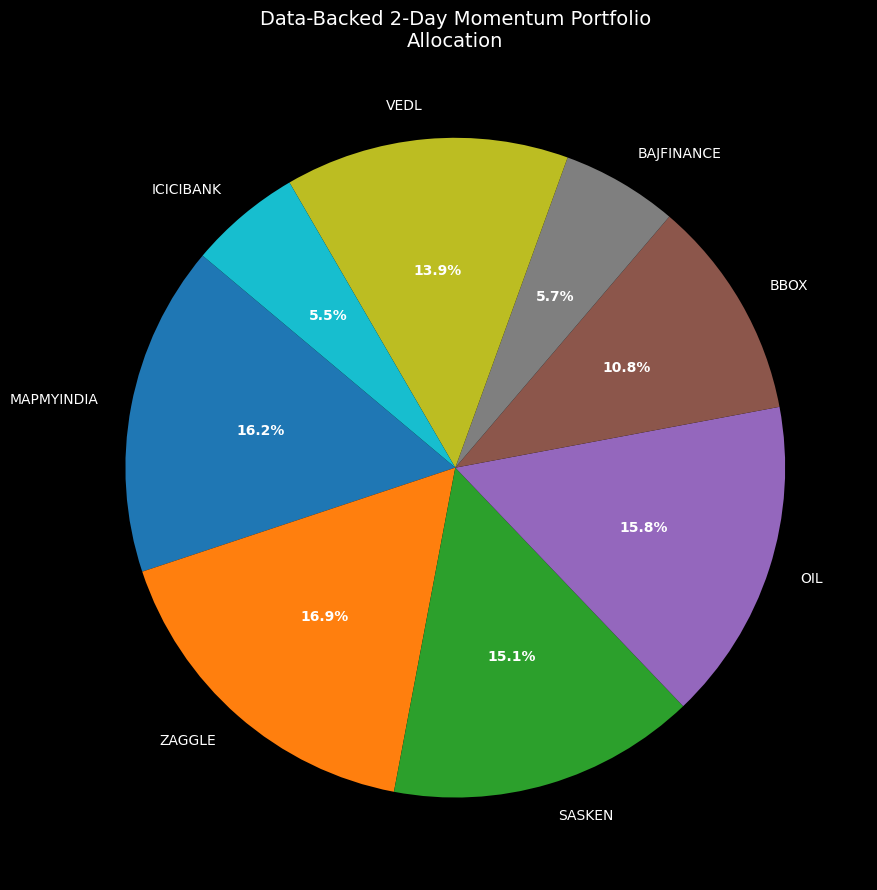

Saved allocation_pie.png


In [13]:
labels = [t.replace(".NS","") for t in alloc_df["Ticker"]]
sizes  = alloc_df["Weight%"].tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct="%1.1f%%",
    colors=colors, startangle=140, textprops={"fontsize": 10}
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
ax.set_title("Data-Backed 2-Day Momentum Portfolio\nAllocation", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/allocation_pie.png", dpi=150)
plt.show()
print("Saved allocation_pie.png")


## Section 12 — Risk Metrics per Stock

In [14]:
risk_rows = []
for tkr in TICKERS:
    r   = indicators[tkr].iloc[-1]
    ret = indicators[tkr]["log_ret"].dropna()
    rsi = r["rsi"]

    exhaustion = "🔴 Overbought" if rsi > 75 else ("🟢 Momentum Zone" if rsi >= 55 else "🟡 Neutral")
    vol_flag   = "⚠ High Vol" if r["rolling_vol"] > 0.45 else "✅ Normal"
    bb_flag    = "⚠ Near Upper BB" if r["bb_pct"] > 0.90 else "✅ Room to Run"

    risk_rows.append({
        "Ticker"     : tkr.replace(".NS",""),
        "RSI"        : round(rsi, 1),
        "RSI_Status" : exhaustion,
        "ATR%"       : round(r["atr_pct"], 2),
        "Ann_Vol%"   : round(r["rolling_vol"]*100, 1),
        "BB_Pos"     : round(r["bb_pct"], 2),
        "BB_Flag"    : bb_flag,
        "Vol_Flag"   : vol_flag,
    })

risk_df = pd.DataFrame(risk_rows)
print(risk_df.to_string(index=False))


    Ticker  RSI      RSI_Status  ATR%  Ann_Vol%  BB_Pos         BB_Flag   Vol_Flag
       OIL 59.0 🟢 Momentum Zone  3.20      41.9    0.82   ✅ Room to Run   ✅ Normal
      VEDL 16.3       🟡 Neutral 17.87     377.2    0.24   ✅ Room to Run ⚠ High Vol
    SASKEN 93.1    🔴 Overbought  4.47      76.8    1.39 ⚠ Near Upper BB ⚠ High Vol
MAPMYINDIA 60.3 🟢 Momentum Zone  4.40      57.6    0.90 ⚠ Near Upper BB ⚠ High Vol
      BBOX 93.7    🔴 Overbought  4.95      48.9    1.02 ⚠ Near Upper BB ⚠ High Vol
    ZAGGLE 60.8 🟢 Momentum Zone  4.72      57.0    1.20 ⚠ Near Upper BB ⚠ High Vol
BAJFINANCE 40.2       🟡 Neutral  2.58      23.6    0.16   ✅ Room to Run   ✅ Normal
 ICICIBANK 18.4       🟡 Neutral  1.82      19.6    0.14   ✅ Room to Run   ✅ Normal


## Section 13 — StockGro Execution Table

In [15]:
print("=" * 80)
print("  STOCKGRO EXECUTION TABLE — 2-DAY MOMENTUM PORTFOLIO")
print("=" * 80)
print(f"  {'Stock':<18} {'Price':>8} {'Alloc%':>7} {'₹Amt':>10} {'D+1 FC%':>9} {'Stop%':>7} {'Target%':>8}")
print("-" * 80)
for _, row in alloc_df.iterrows():
    tkr   = row["Ticker"]
    price = forecasts.get(tkr, {}).get("current", 0)
    fc1   = forecasts.get(tkr, {}).get("fc_ret1%", 0)
    stop  = -4.5 if row["MomentumScore"] > 30 else -6.0
    tgt   = fc1 * 2.5 if fc1 > 0 else 5.0
    name  = tkr.replace(".NS","")
    print(f"  {name:<18} {price:>8.2f} {row['Weight%']:>7.1f}% {row['Alloc_INR']:>10,} "
          f"{fc1:>+9.2f}% {stop:>7.1f}% {tgt:>+8.2f}%")
print("=" * 80)
print("\n⚠  RULES:")
print("  1. Enter within first 30 minutes of market open")
print("  2. Exit ALL positions at T+1 market close (15:20 IST)")
print("  3. If portfolio drops >4% on Day 1 → exit ZAGGLE, halve MAPMYINDIA immediately")
print("  4. Do NOT chase stocks that opened >3% above prior close — skip or halve size")


  STOCKGRO EXECUTION TABLE — 2-DAY MOMENTUM PORTFOLIO
  Stock                 Price  Alloc%       ₹Amt   D+1 FC%   Stop%  Target%
--------------------------------------------------------------------------------
  MAPMYINDIA          1077.00    16.2%    162,089     -5.71%    -4.5%    +5.00%
  ZAGGLE               252.09    16.9%    169,490     -1.00%    -4.5%    +5.00%
  SASKEN              1634.60    15.1%    151,274     -7.90%    -4.5%    +5.00%
  OIL                  456.00    15.8%    158,315     +1.35%    -4.5%    +3.37%
  BBOX                 788.10    10.8%    107,784    -28.08%    -4.5%    +5.00%
  BAJFINANCE           936.05     5.7%     57,215     -0.78%    -6.0%    +5.00%
  VEDL                 298.40    13.9%    139,236    +49.09%    -6.0%  +122.72%
  ICICIBANK           1266.40     5.5%     54,596     +4.09%    -6.0%   +10.22%

⚠  RULES:
  1. Enter within first 30 minutes of market open
  2. Exit ALL positions at T+1 market close (15:20 IST)
  3. If portfolio drops >4% on D